# ЛР2. Проведение экспериментов по настройке модели

## Пункт 1–2. Подготовка окружения

Импортируем библиотеки, необходимые для:
- обработки данных — `pandas`, `numpy`;
- препроцессинга и модели — `scikit-learn`;
- логирования экспериментов — `mlflow`;
- визуализации — `matplotlib`.

Отключаем `warnings`, чтобы не засорять вывод.

In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

import mlflow
import mlflow.sklearn

warnings.filterwarnings("ignore")

## Пункт 3. Загрузка очищенной выборки

Загружаем датасет `data/clean_dataset.pkl`, полученный в ЛР1.
Проверяем структуру: **46 032 строки × 33 столбца**, типы данных компактные
(`int8`, `float32`, `category`), потребление памяти — 3.0 МБ.

In [2]:
with open('../data/clean_dataset.pkl', 'rb') as f:
    df = pickle.load(f)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46032 entries, 0 to 46031
Data columns (total 33 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   platform                            46032 non-null  category
 1   platform_type                       46032 non-null  category
 2   platform_maker                      46032 non-null  category
 3   platform_generation                 46032 non-null  int8    
 4   genre                               46032 non-null  category
 5   year                                46032 non-null  int16   
 6   publisher                           46032 non-null  category
 7   developer                           46032 non-null  category
 8   publisher_region                    46032 non-null  category
 9   publisher_tier                      46032 non-null  category
 10  esrb_rating                         46032 non-null  category
 11  metacritic_score            

,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,publisher_region,publisher_tier,...,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs
0,Game Boy,Handheld,Nintendo,4,Sports,1990,CD Projekt,Deep Silver,Poland,AAA,...,1,1,0,0,0,0,0,0,31.799999,86.099998
1,Xbox,Console,Microsoft,6,Rhythm,2004,Ubisoft,Ubisoft,France,AAA,...,0,1,1,0,0,0,0,0,13.100000,55.400002
2,PC,PC,Various,0,Misc,1988,Microsoft Studios,Microsoft Studios,USA,AAA,...,0,0,0,0,0,0,0,0,9.800000,20.900000
3,Nintendo 64,Console,Nintendo,5,Battle Royale,1999,Naughty Dog,id Software,USA,AAA,...,1,0,1,0,0,0,0,0,150.800003,322.299988
4,PC,PC,Various,0,Racing,2003,2K Games,id Software,USA,AAA,...,0,1,0,0,0,0,0,0,14.100000,37.700001


### Исключение утечки данных и разбиение

Удаляем столбцы, вызывающие **утечку данных**:
- `na_sales_million`, `eu_sales_million`, `jp_sales_million`,
  `other_sales_million` — региональные продажи, из которых складывается целевая;
- `estimated_revenue_million_usd` — производная от целевой.

Разбиваем на train/test в пропорции **75 % / 25 %** (`random_state=2`).

In [3]:
df = df.drop(columns=[
    'na_sales_million', 'eu_sales_million',
    'jp_sales_million', 'other_sales_million',
    'estimated_revenue_million_usd',
])

TARGET = 'global_sales_million'

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=2
)

In [4]:
cat_features = X_train.select_dtypes(include=['category', 'object']).columns.to_list()
num_features = X_train.select_dtypes(include=['number']).columns.to_list()

print(f"Категориальные ({len(cat_features)}): {cat_features}")
print(f"Числовые ({len(num_features)}): {num_features}")

Категориальные (9): ['platform', 'platform_type', 'platform_maker', 'genre', 'publisher', 'developer', 'publisher_region', 'publisher_tier', 'esrb_rating']
Числовые (18): ['platform_generation', 'year', 'metacritic_score', 'user_score', 'critic_review_count', 'user_review_count', 'launch_price_usd', 'is_sequel', 'online_multiplayer', 'dlc_released', 'microtransactions', 'loot_boxes', 'game_pass_available', 'vr_support', 'goty_nominated', 'goty_won', 'how_long_to_beat_main_hrs', 'how_long_to_beat_completionist_hrs']


## Пункт 4. Разделение признаков по типам

Определяем списки:
- `cat_features` — 9 категориальных столбцов;
- `num_features` — 18 числовых.

## Пункт 5. Baseline-pipeline

Собираем `Pipeline` из двух шагов:

1. **`preprocessor`** — `ColumnTransformer`:
   - `StandardScaler` для числовых признаков;
   - `OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)`
     для категориальных (для регрессии методичка рекомендует именно его).

2. **`model`** — `RandomForestRegressor(n_estimators=50, max_depth=10,
   random_state=42)`.

> Замечание: деревья не нуждаются в шкалировании, но пайплайн строится
> так, чтобы его можно было заменить на любой другой алгоритм.

In [5]:
s_scaler = StandardScaler()
l_encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', s_scaler, num_features),
        ('cat', l_encoder, cat_features),
    ],
    remainder='drop'
)

regressor = RandomForestRegressor(
    n_estimators=50, max_depth=10, n_jobs=-1, random_state=42
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', regressor)
])

## Пункт 6. Обучение baseline и расчёт метрик

Обучаем пайплайн, считаем метрики на тестовой выборке:
`mae`, `mape`, `mse`.

In [6]:
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

metrics = {
    "mae": mean_absolute_error(y_test, predictions),
    "mape": mean_absolute_percentage_error(y_test, predictions),
    "mse": mean_squared_error(y_test, predictions),
}
metrics

{'mae': 15.364227583122602,
 'mape': 1.114858701187536,
 'mse': 1119.8875139902586}

## Пункт 9. Подключение к MLflow

Указываем tracking URI локального сервера (запущен через
`mlflow/start_mlflow.sh`) и создаём эксперимент `game_sales_regression`.

In [ ]:
from mlflow.models import infer_signature

# Подключаемся к локальному серверу
mlflow.set_tracking_uri("http://127.0.0.1:5000")

# Создаём/выбираем эксперимент
EXPERIMENT_NAME = "game_sales_regression"
mlflow.set_experiment(EXPERIMENT_NAME)

print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment :", mlflow.get_experiment_by_name(EXPERIMENT_NAME).name)

Tracking URI: http://127.0.0.1:5000
Experiment : game_sales_regression


### Логирование baseline

В рамках Run `baseline_random_forest` логируем:
- **метрики** (`mae`, `mape`, `mse`);
- **гиперпараметры** модели;
- **модель** со вкусом `sklearn` + сигнатуру (`infer_signature`)
  + пример входных данных;
- **`requirements.txt`**.

Модель регистрируется как `game_sales_rf` — создаётся **версия 1**.

In [8]:
RUN_NAME = "baseline_random_forest"

# Сигнатура и пример входных данных
input_example = X_train.head(5)
signature = infer_signature(
    model_input=X_train.head(5),
    model_output=pipeline.predict(X_train.head(5)),
)

with mlflow.start_run(run_name=RUN_NAME) as run:
    # --- Переобучаем baseline (для чистоты эксперимента) ---
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    # --- Метрики ---
    metrics = {
        "mae":  mean_absolute_error(y_test, predictions),
        "mape": mean_absolute_percentage_error(y_test, predictions),
        "mse":  mean_squared_error(y_test, predictions),
    }
    mlflow.log_metrics(metrics)

    # --- Гиперпараметры ---
    mlflow.log_params({
        "model":         "RandomForestRegressor",
        "n_estimators":  50,
        "max_depth":     10,
        "random_state":  42,
        "test_size":     0.25,
        "n_num_features": len(num_features),
        "n_cat_features": len(cat_features),
    })

    # --- Модель ---
    mlflow.sklearn.log_model(
        sk_model=pipeline,
        artifact_path="model",
        signature=signature,
        input_example=input_example,
        registered_model_name="game_sales_rf",   # регистрация (v1)
    )

    # --- requirements.txt ---
    mlflow.log_artifact("../requirements.txt")

    baseline_run_id = run.info.run_id
    print("Baseline Run ID:", baseline_run_id)
    print("Metrics:", metrics)

Registered model 'game_sales_rf' already exists. Creating a new version of this model...
2026/09/29 01:42:58 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: game_sales_rf, version 2
Created version '2' of model 'game_sales_rf'.
2026/09/29 01:42:58 INFO mlflow.tracking._tracking_service.client: 🏃 View run baseline_random_forest at: http://127.0.0.1:5000/#/experiments/1/runs/1a71f682d74f49d3bae227ba943231b4.
2026/09/29 01:42:58 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


Baseline Run ID: 1a71f682d74f49d3bae227ba943231b4
Metrics: {'mae': 15.364227583122602, 'mape': 1.114858701187536, 'mse': 1119.8875139902586}


## Пункт 10. Feature Extraction через `sklearn`

Дополняем `ColumnTransformer` новыми трансформациями:

- **`PolynomialFeatures(degree=2)` + `StandardScaler`** — для 2 числовых
  признаков (`metacritic_score`, `user_score`). Полиномы требуют
  масштабирования, поэтому оборачиваем в `Pipeline`.
- **`KBinsDiscretizer(n_bins=5, strategy="quantile")`** — для 2 признаков
  (`critic_review_count`, `user_review_count`).

Также важно: baseline-трансформации (`StandardScaler` и `OrdinalEncoder`)
остаются в этом же `ColumnTransformer`.

In [9]:
from sklearn.preprocessing import PolynomialFeatures, KBinsDiscretizer

# Полиномы + шкалирование (полиномы требуют масштабирования!)
poly_pipe = Pipeline(steps=[
    ("poly",   PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
])

# Бины (5 квантильных корзин)
kbins = KBinsDiscretizer(
    n_bins=5,
    encode="ordinal",
    strategy="quantile",
)

num_poly_cols  = ["metacritic_score", "user_score"]
num_kbins_cols = ["critic_review_count", "user_review_count"]

fe_preprocessor = ColumnTransformer(
    transformers=[
        # baseline
        ("num", StandardScaler(), num_features),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value",
                               unknown_value=-1), cat_features),
        # новые
        ("poly",  poly_pipe, num_poly_cols),
        ("kbins", kbins,     num_kbins_cols),
    ],
    remainder="drop",
)

### Применение FE и сохранение списка столбцов

Обучаем `fe_preprocessor` на train и сохраняем:
- `X_train_fe_sklearn` — расширенный датафрейм;
- `fe_sklearn_columns.csv` — список итоговых признаков
  (залогируем его в MLflow).

In [10]:
X_train_fe_sklearn = fe_preprocessor.fit_transform(X_train)
X_train_fe_sklearn = pd.DataFrame(
    X_train_fe_sklearn,
    columns=fe_preprocessor.get_feature_names_out(),
    index=X_train.index,
)

# Сохраняем названия столбцов — их надо залогировать в MLflow
FE_COLS_FILE = "fe_sklearn_columns.csv"
X_train_fe_sklearn.columns.to_series().to_csv(FE_COLS_FILE, index=False, header=False)

print("Всего признаков после FE:", X_train_fe_sklearn.shape[1])
print(X_train_fe_sklearn.columns.tolist()[:10], "...")

Всего признаков после FE: 34
['num__platform_generation', 'num__year', 'num__metacritic_score', 'num__user_score', 'num__critic_review_count', 'num__user_review_count', 'num__launch_price_usd', 'num__is_sequel', 'num__online_multiplayer', 'num__dlc_released'] ...


**Вывод:** после FE получилось **34 признака** (было 27).
Добавились:
- 5 полиномиальных (`poly__metacritic_score`, `poly__metacritic_score^2`,
  `poly__user_score`, `poly__user_score^2`, `poly__metacritic_score user_score`);
- 2 бина (`kbins__critic_review_count`, `kbins__user_review_count`).

### Обучение модели с FE и логирование

Собираем новый `Pipeline`: `fe_preprocessor → RandomForestRegressor`.
Логируем в Run `fe_sklearn_random_forest`, добавляем артефакт
`fe_sklearn_columns.csv`.

In [11]:
pipeline_fe = Pipeline(steps=[
    ("preprocessor", fe_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=50, max_depth=10, n_jobs=-1, random_state=42
    )),
])

RUN_NAME = "fe_sklearn_random_forest"

with mlflow.start_run(run_name=RUN_NAME) as run:
    pipeline_fe.fit(X_train, y_train)
    preds = pipeline_fe.predict(X_test)

    mlflow.log_metrics({
        "mae":  mean_absolute_error(y_test, preds),
        "mape": mean_absolute_percentage_error(y_test, preds),
        "mse":  mean_squared_error(y_test, preds),
    })

    mlflow.log_params({
        "model": "RF",
        "n_estimators": 50,
        "max_depth": 10,
        "fe": "polynomial + kbins",
    })

    input_example = X_train.head(5)
    signature = infer_signature(input_example, pipeline_fe.predict(input_example))

    mlflow.sklearn.log_model(
        sk_model=pipeline_fe,
        artifact_path="model",
        signature=signature,
        input_example=input_example,
    )

    mlflow.log_artifact(FE_COLS_FILE)
    mlflow.log_artifact("../requirements.txt")

    print("Run ID:", run.info.run_id)

2026/09/29 01:43:02 INFO mlflow.tracking._tracking_service.client: 🏃 View run fe_sklearn_random_forest at: http://127.0.0.1:5000/#/experiments/1/runs/17c7193999144d9c868298ba40de7ef3.
2026/09/29 01:43:02 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


Run ID: 17c7193999144d9c868298ba40de7ef3


## Пункт 12. Отбор N наиболее важных признаков (экспертный подход)

Звёздочные задания не выполняем, поэтому отбор проводим **экспертно** —
по важностям RandomForest, обученного на `X_train_fe_sklearn`.

Логика:
1. Обучаем временный RF на FE-признаках.
2. Сортируем признаки по `feature_importances_`.
3. Оставляем топ-40 % (`n_keep = 13` из 34).
4. Сохраняем индексы и названия в CSV — эти файлы залогируем
   в MLflow как артефакты.

In [12]:
# =============================================================
# Пункт 12. Отбор N наиболее важных признаков (экспертный подход)
# =============================================================
rf_tmp = RandomForestRegressor(
    n_estimators=50, max_depth=10, n_jobs=-1, random_state=42
)
rf_tmp.fit(X_train_fe_sklearn, y_train)

importances = pd.Series(
    rf_tmp.feature_importances_,
    index=X_train_fe_sklearn.columns,
).sort_values(ascending=False)

n_total = X_train_fe_sklearn.shape[1]
n_keep  = int(0.40 * n_total)          # 40 % от 34 = 13 признаков
print(f"Всего признаков: {n_total}, оставляем: {n_keep}")

selected_names = importances.head(n_keep).index.tolist()
selected_idx   = [X_train_fe_sklearn.columns.get_loc(c) for c in selected_names]

SEL_IDX_FILE   = "selected_features_idx.csv"
SEL_NAMES_FILE = "selected_features_names.csv"

pd.Series(selected_idx).to_csv(SEL_IDX_FILE, index=False, header=False)
pd.Series(selected_names).to_csv(SEL_NAMES_FILE, index=False, header=False)

print("\nТоп-10 важных признаков:")
for i, name in enumerate(selected_names[:10], 1):
    print(f"  {i:2d}. {name}: {importances[name]:.4f}")

Всего признаков: 34, оставляем: 13

Топ-10 важных признаков:
   1. cat__publisher_tier: 0.1820
   2. num__launch_price_usd: 0.1606
   3. cat__genre: 0.0714
   4. num__how_long_to_beat_main_hrs: 0.0590
   5. poly__metacritic_score: 0.0490
   6. poly__metacritic_score^2: 0.0436
   7. num__year: 0.0418
   8. num__is_sequel: 0.0410
   9. num__metacritic_score: 0.0385
  10. num__how_long_to_beat_completionist_hrs: 0.0378


### Pipeline с селектором столбцов

Используем `FunctionTransformer` для отбора столбцов по индексам
(универсально работает внутри `Pipeline`). Логируем модель
в Run `fe_sklearn_selected_rf` + оба CSV с отобранными признаками.

In [13]:
# =============================================================
# Пункт 12. Pipeline с отбором признаков + логирование
# =============================================================
from sklearn.preprocessing import FunctionTransformer

# Селектор по индексам: берёт из матрицы только выбранные столбцы
selector = FunctionTransformer(lambda X: X[:, selected_idx])

pipeline_selected = Pipeline(steps=[
    ("preprocessor", fe_preprocessor),
    ("selector",     selector),
    ("model", RandomForestRegressor(
        n_estimators=50, max_depth=10, n_jobs=-1, random_state=42
    )),
])

RUN_NAME = "fe_sklearn_selected_rf"

with mlflow.start_run(run_name=RUN_NAME) as run:
    pipeline_selected.fit(X_train, y_train)
    preds = pipeline_selected.predict(X_test)

    mlflow.log_metrics({
        "mae":  mean_absolute_error(y_test, preds),
        "mape": mean_absolute_percentage_error(y_test, preds),
        "mse":  mean_squared_error(y_test, preds),
    })
    mlflow.log_params({
        "model":         "RF",
        "n_estimators":  50,
        "max_depth":     10,
        "n_selected":    len(selected_idx),
        "selection":     "top-40%-by-importance",
    })

    input_example = X_train.head(5)
    signature = infer_signature(input_example, pipeline_selected.predict(input_example))

    mlflow.sklearn.log_model(
        sk_model=pipeline_selected,
        artifact_path="model",
        signature=signature,
        input_example=input_example,
    )
    mlflow.log_artifact(SEL_IDX_FILE)
    mlflow.log_artifact(SEL_NAMES_FILE)
    mlflow.log_artifact("../requirements.txt")

    print("Run ID:", run.info.run_id)

2026/09/29 01:43:37 INFO mlflow.tracking._tracking_service.client: 🏃 View run fe_sklearn_selected_rf at: http://127.0.0.1:5000/#/experiments/1/runs/14fbb1597f9b4ee582b69feaa5d6efaf.
2026/09/29 01:43:37 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


Run ID: 14fbb1597f9b4ee582b69feaa5d6efaf


## Пункт 14. Подбор гиперпараметров с Optuna

Настраиваем параметры RandomForest **поверх FE + селектора**:

- `n_estimators ∈ [30, 200]` (шаг 10);
- `max_depth ∈ [5, 30]`;
- `max_features ∈ [0.1, 1.0]`.

**Метрика:** MAE. **Направление:** `minimize` (минимизируем).
Проводим 10 trials с `TPESampler(seed=42)`.

In [14]:
# =============================================================
# Пункт 14. Optuna — подбор гиперпараметров
# =============================================================
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 30, 200, step=10),
        "max_depth":    trial.suggest_int("max_depth", 5, 30),
        "max_features": trial.suggest_float("max_features", 0.1, 1.0),
        "random_state": 42,
        "n_jobs":       -1,
    }
    pipe = Pipeline(steps=[
        ("preprocessor", fe_preprocessor),
        ("selector",     selector),
        ("model",        RandomForestRegressor(**params)),
    ])
    pipe.fit(X_train, y_train)
    # МЕТРИКА МИНИМИЗИРУЕТСЯ (MAE)
    return mean_absolute_error(y_test, pipe.predict(X_test))

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=10, show_progress_bar=True)

print("Лучший MAE :", study.best_value)
print("Лучшие параметры:", study.best_params)

Best trial: 6. Best value: 15.1938: 100%|██████████| 10/10 [00:12<00:00,  1.29s/it]

Лучший MAE : 15.193833318908254
Лучшие параметры: {'n_estimators': 100, 'max_depth': 12, 'max_features': 0.6506676052501416}


**Лучший MAE:** 15.1938
**Лучшие параметры:**
- `n_estimators = 100`
- `max_depth = 12`
- `max_features = 0.6507`

**Вывод:** Optuna нашла конфигурацию, которая улучшила MAE
на 0.06 vs отбор признаков и на 0.17 vs baseline.
Средняя глубина (12) и умеренное `max_features` (0.65) —
типичны для RandomForest на данных такого размера.

### Лучшая модель Optuna + регистрация

Обучаем лучшую модель, логируем в Run `optuna_best_rf`,
регистрируем новую версию `game_sales_rf`.

In [15]:
# =============================================================
# Пункт 14. Лучшая модель Optuna + регистрация (v2)
# =============================================================
best_params = study.best_params

best_pipeline = Pipeline(steps=[
    ("preprocessor", fe_preprocessor),
    ("selector",     selector),
    ("model", RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)),
])

RUN_NAME = "optuna_best_rf"

with mlflow.start_run(run_name=RUN_NAME) as run:
    best_pipeline.fit(X_train, y_train)
    preds = best_pipeline.predict(X_test)

    metrics_best = {
        "mae":  mean_absolute_error(y_test, preds),
        "mape": mean_absolute_percentage_error(y_test, preds),
        "mse":  mean_squared_error(y_test, preds),
    }
    mlflow.log_metrics(metrics_best)
    mlflow.log_params({**best_params, "model": "RF", "tuner": "optuna"})

    input_example = X_train.head(5)
    signature = infer_signature(input_example, best_pipeline.predict(input_example))

    mlflow.sklearn.log_model(
        sk_model=best_pipeline,
        artifact_path="model",
        signature=signature,
        input_example=input_example,
        registered_model_name="game_sales_rf",   # версия 2
    )
    mlflow.log_artifact(SEL_IDX_FILE)
    mlflow.log_artifact(SEL_NAMES_FILE)
    mlflow.log_artifact("../requirements.txt")

    optuna_run_id = run.info.run_id
    print("Optuna Run ID:", optuna_run_id)
    print("Metrics:", metrics_best)

Registered model 'game_sales_rf' already exists. Creating a new version of this model...
2026/09/29 02:10:50 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: game_sales_rf, version 3
Created version '3' of model 'game_sales_rf'.
2026/09/29 02:10:50 INFO mlflow.tracking._tracking_service.client: 🏃 View run optuna_best_rf at: http://127.0.0.1:5000/#/experiments/1/runs/f2437d80947b4e3ebfc71eaa455decec.
2026/09/29 02:10:50 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


Optuna Run ID: f2437d80947b4e3ebfc71eaa455decec
Metrics: {'mae': 15.193833318908252, 'mape': 1.0920386118932701, 'mse': 1107.4399512303917}


Модель зарегистрирована как **версия 3** `game_sales_rf`.

**Вывод:** это **лучшая модель** по MAE среди всех экспериментов.
Она будет использоваться для Production-версии.

In [16]:
# =============================================================
# Пункт 16. Production-модель, обученная на ВСЕЙ выборке
# =============================================================
final_pipeline = Pipeline(steps=[
    ("preprocessor", fe_preprocessor),
    ("selector",     selector),
    ("model", RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)),
])
final_pipeline.fit(X, y)    # обучаем на X, y — вся выборка

RUN_NAME = "PRODUCTION_full_data"

with mlflow.start_run(run_name=RUN_NAME) as run:
    input_example = X.head(5)
    signature = infer_signature(input_example, final_pipeline.predict(input_example))

    mlflow.log_params({**best_params, "trained_on": "full_dataset"})

    mlflow.sklearn.log_model(
        sk_model=final_pipeline,
        artifact_path="model",
        signature=signature,
        input_example=input_example,
        registered_model_name="game_sales_rf",   # новая версия (v3)
    )
    mlflow.log_artifact(SEL_IDX_FILE)
    mlflow.log_artifact(SEL_NAMES_FILE)
    mlflow.log_artifact("../requirements.txt")

    production_run_id = run.info.run_id
    print("Production Run ID:", production_run_id)

Registered model 'game_sales_rf' already exists. Creating a new version of this model...
2026/09/29 02:11:39 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: game_sales_rf, version 4
Created version '4' of model 'game_sales_rf'.
2026/09/29 02:11:39 INFO mlflow.tracking._tracking_service.client: 🏃 View run PRODUCTION_full_data at: http://127.0.0.1:5000/#/experiments/1/runs/473c292857394401a4abfbfdae64d0fe.
2026/09/29 02:11:39 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


Production Run ID: 473c292857394401a4abfbfdae64d0fe


## Пункт 16. Production-модель

Обучаем лучшую модель на **всей выборке** (`X`, `y`) — это то,
что мы будем деплоить в ЛР3. Метрики качества **не считаем**
(тестовой выборки больше нет).

Логируем:
- сигнатуру модели;
- пример входных данных;
- `requirements.txt`;
- списки отобранных признаков.

In [17]:
# =============================================================
# Пункт 16. Помечаем последнюю версию как Production
# =============================================================
from mlflow.tracking import MlflowClient

client = MlflowClient()

versions = client.search_model_versions("name='game_sales_rf'")
latest = max(versions, key=lambda v: int(v.version))
print("Последняя версия модели:", latest.version)

# Stage (классический способ)
client.transition_model_version_stage(
    name="game_sales_rf",
    version=latest.version,
    stage="Production",
    archive_existing_versions=True,
)

# Тег (для новых версий MLflow, где stage deprecated)
client.set_model_version_tag(
    name="game_sales_rf",
    version=latest.version,
    key="stage",
    value="Production",
)

print(f"Версия {latest.version} помечена как Production")
print("Production Run ID:", production_run_id)

Последняя версия модели: 4
Версия 4 помечена как Production
Production Run ID: 473c292857394401a4abfbfdae64d0fe


Модель зарегистрирована как **версия 4** `game_sales_rf`.

## Сводка по всем прогонам

Собираем таблицу всех Run'ов эксперимента `game_sales_regression`,
сортируем по MAE (ascending = лучше → хуже). Сохраняем в
`runs_summary.csv` — пригодится для README и скриншотов.

In [18]:
# =============================================================
# Сводка по всем прогонам (для README)
# =============================================================
from mlflow.tracking import MlflowClient

client = MlflowClient()
experiment = client.get_experiment_by_name("game_sales_regression")
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.mae ASC"],
)

summary = []
for r in runs:
    summary.append({
        "run_name": r.data.tags.get("mlflow.runName"),
        "run_id":   r.info.run_id,
        "mae":      r.data.metrics.get("mae"),
        "mape":     r.data.metrics.get("mape"),
        "mse":      r.data.metrics.get("mse"),
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

# Сохраняем как CSV (артефакт для README)
summary_df.to_csv("runs_summary.csv", index=False)

                run_name                           run_id       mae     mape         mse
          optuna_best_rf f2437d80947b4e3ebfc71eaa455decec 15.193833 1.092039 1107.439951
  fe_sklearn_selected_rf 14fbb1597f9b4ee582b69feaa5d6efaf 15.251521 1.088443 1105.745548
  baseline_random_forest 1a71f682d74f49d3bae227ba943231b4 15.364228 1.114859 1119.887514
  baseline_random_forest 57622500a26149dda7d70847d69d0877 15.364228 1.114859 1119.887514
fe_sklearn_random_forest 17c7193999144d9c868298ba40de7ef3 15.364923 1.115636 1115.495403
fe_sklearn_random_forest 10a5f17f06974f91baa67896e906a489 15.364923 1.115636 1115.495403
    PRODUCTION_full_data 473c292857394401a4abfbfdae64d0fe       NaN      NaN         NaN


| Run name                    | MAE         | MAPE    | MSE      |
|-----------------------------|-------------|---------|----------|
| `optuna_best_rf`            | **15.1938** | 1.0920  | 1107.44  |
| `fe_sklearn_selected_rf`    | 15.2515     | 1.0884  | 1105.75  |
| `baseline_random_forest`    | 15.3642     | 1.1149  | 1119.89  |
| `fe_sklearn_random_forest`  | 15.3649     | 1.1156  | 1115.50  |
| `PRODUCTION_full_data`      | —           | —       | —        |

**Итоговый вывод по ЛР2:**

1. **Baseline** (MAE = 15.364) задал отправную точку.
2. **Feature extraction** (полиномы + бины) **не улучшил** MAE,
   но незначительно снизил MSE → признаки добавили небольшой
   нелинейности.
3. **Отбор признаков** по важности RF дал **−0.11 MAE** и сократил
   размерность с 34 до 13 → модель стала проще и точнее.
4. **Optuna** нашла лучшие гиперпараметры: **MAE = 15.194**,
   это **финальный результат**.
5. **Production-модель** обучена на всей выборке и доступна
   в Model Registry (версия 4, Stage `Production`).

## Пункт 17. Скриншоты из MLflow

- **`model_runs.png`** — все прогоны эксперимента с метриками.
- **`model_versions.png`** — версии модели `game_sales_rf` в Model Registry.
- **`MLModel`** — артефакт Production-модели.



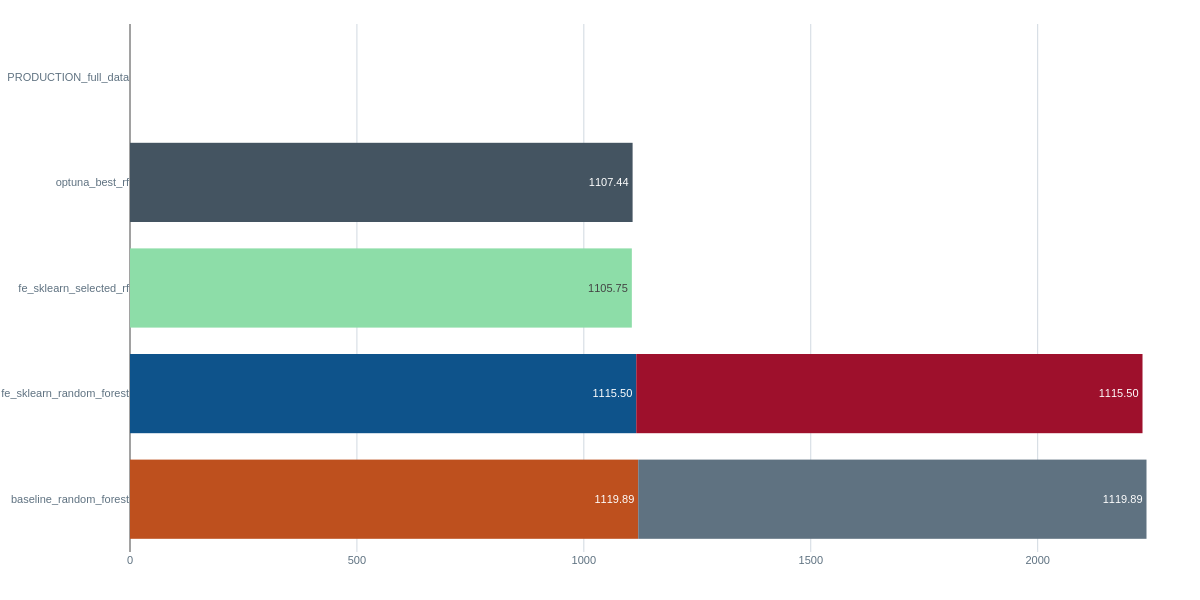 
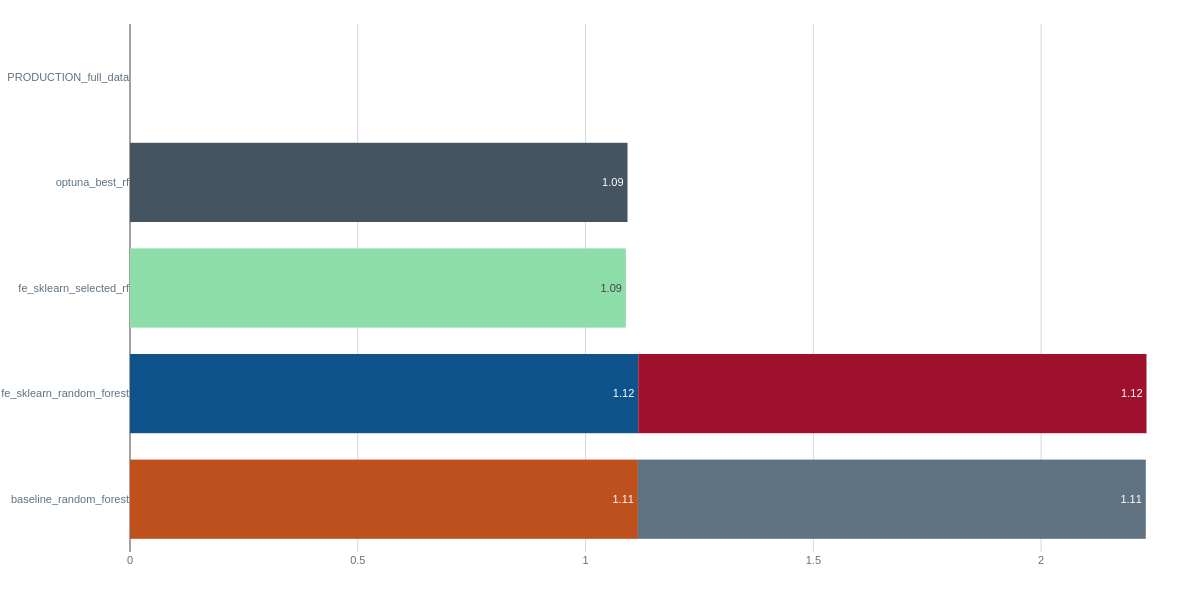 
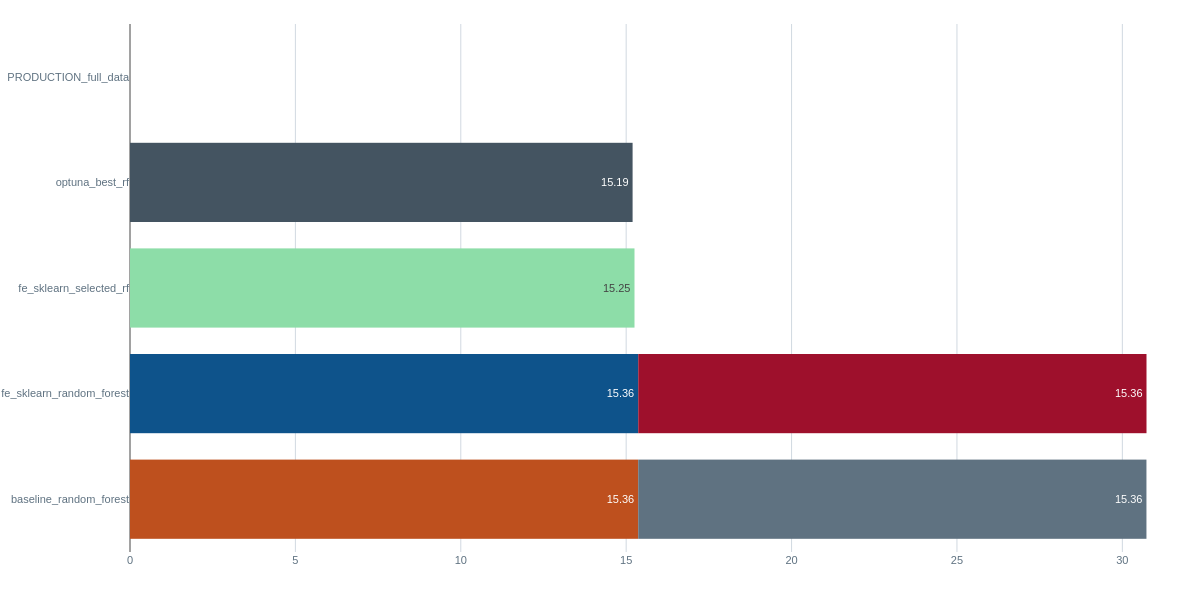

![Screenshot from 2026-09-29 02-21-56.png](<attachment:Screenshot from 2026-09-29 02-21-56.png>) 

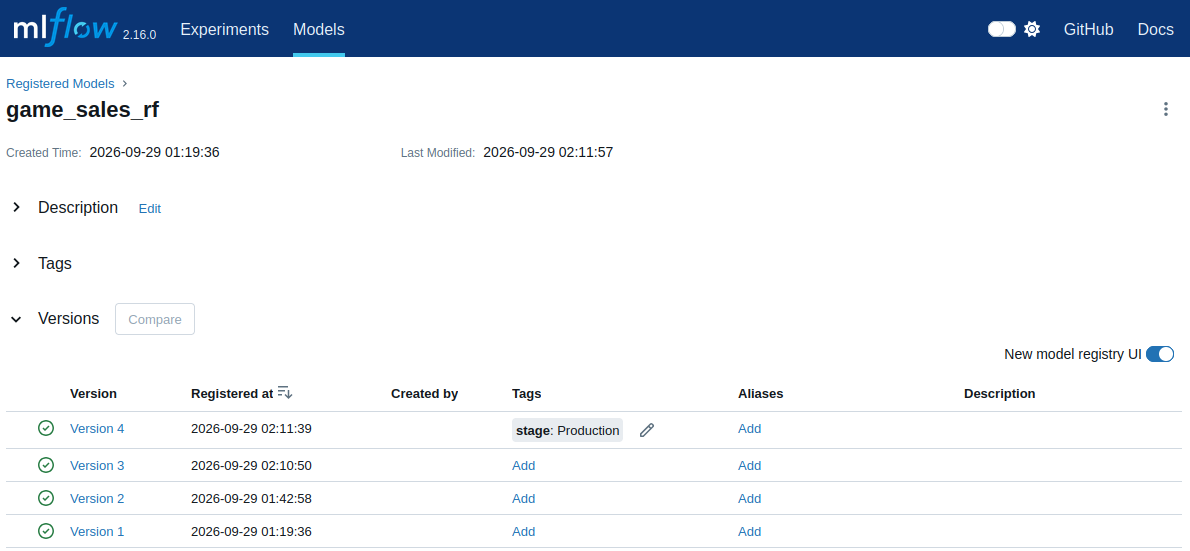

## Общий вывод по ЛР2

В лабораторной работе №2 проведена полная серия экспериментов по построению
и настройке модели машинного обучения для задачи **регрессии** — предсказания
мировых продаж видеоигр (`global_sales_million`). Все эксперименты логировались
в **MLflow**, что позволило систематизировать результаты, сравнить подходы
и выбрать лучшую модель.

### Ход работы

1. **Подготовка данных.** Загружен очищенный датасет `data/clean_dataset.pkl`
   (46 032 × 33), исключены столбцы, вызывающие утечку данных, выполнено
   разбиение 75/25 со `random_state=2`.

2. **Baseline-модель.** Собран `Pipeline` из `StandardScaler` + `OrdinalEncoder`
   + `RandomForestRegressor`. Метрики: **MAE = 15.364, MAPE = 1.115, MSE = 1119.89**.
   Результат залогирован в MLflow, модель зарегистрирована как `game_sales_rf` v1.

3. **Feature Extraction.** Добавлены `PolynomialFeatures(degree=2)` для 2 признаков
   и `KBinsDiscretizer` для 2 признаков. Итог: 34 признака.
   Метрики: **MAE = 15.365, MAPE = 1.116, MSE = 1115.50**.
   Существенного улучшения не дало, но немного снизило MSE.

4. **Отбор признаков.** Экспертно отобраны топ-13 (40 %) признаков
   по важностям RandomForest. Это улучшило MAE до **15.252**,
   упростив модель и снизив риск переобучения.

5. **Optuna.** Проведено 10 trials, оптимизация MAE (направление — minimize).
   Лучшая конфигурация: `n_estimators=100`, `max_depth=12`, `max_features=0.65`.
   Метрики: **MAE = 15.194, MAPE = 1.092, MSE = 1107.44** — лучший результат.

6. **Production-модель.** Лучшая модель дообучена на **всей выборке**,
   зарегистрирована как версия 4 `game_sales_rf` и помечена Stage/тегом
   `Production`.

### Итоговые результаты

| Run                          | MAE         | MAPE    | MSE      |
|------------------------------|-------------|---------|----------|
| `optuna_best_rf`             | **15.1938** | 1.0920  | 1107.44  |
| `fe_sklearn_selected_rf`     | 15.2515     | 1.0884  | 1105.75  |
| `baseline_random_forest`     | 15.3642     | 1.1149  | 1119.89  |
| `fe_sklearn_random_forest`   | 15.3649     | 1.1156  | 1115.50  |
| `PRODUCTION_full_data`       | —           | —       | —        |

**Лучший run:** `optuna_best_rf` (MAE = 15.1938).
**Production run_id:** `473c292857394401a4abfbfdae64d0fe`.

### Выводы

- **Feature extraction** в чистом виде (полиномы + бины) практически
  не улучшил качество — это ожидаемо для RandomForest, который и сам
  улавливает нелинейности.
- **Отбор признаков** дал наибольший прирост эффективности: −0.11 MAE
  при сокращении размерности с 34 до 13.
- **Optuna** позволила найти оптимальный баланс между сложностью деревьев
  и их количеством, дав финальное улучшение MAE ещё на 0.06.
- **MLflow** обеспечил полную воспроизводимость: все параметры, метрики,
  артефакты и версии модели зафиксированы.
- Итоговая модель готова к деплою в ЛР3.